In [1]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
import sklearn

import struct

sns.set_theme()

In [2]:
data_dir = "/home/patrick/Projects/DataScienceAndMachineLearning/Data/"

names = ["displacement", "mpg", "cylinders", "horsepower", "weight", "acceleration", "model_year", "origin", "car_name"]
df = pd.read_table(data_dir + 'auto-mpg.data', sep = r'\s+', names=names)
df = df.drop(columns=["car_name"])

df["is_USA"] = (df["origin"] == 1).astype(np.int64)
df["is_Europe"] = (df["origin"] == 2).astype(np.int64)
df["is_Japan"] = (df["origin"] == 3).astype(np.int64)

df["horsepower"] = df["horsepower"].replace("?", np.nan).astype(np.float64)
meanval = df["horsepower"].mean()
df["horsepower"] = df["horsepower"].fillna(meanval)
df = df.drop(columns=["origin", "model_year"])
df = df.astype(np.float64)
# print(np.where(df == "?"))
df

,displacement,mpg,cylinders,horsepower,weight,acceleration,is_USA,is_Europe,is_Japan
0,18.0,8.0,307.0,130.0,3504.0,12.0,1.0,0.0,0.0
1,15.0,8.0,350.0,165.0,3693.0,11.5,1.0,0.0,0.0
2,18.0,8.0,318.0,150.0,3436.0,11.0,1.0,0.0,0.0
3,16.0,8.0,304.0,150.0,3433.0,12.0,1.0,0.0,0.0
4,17.0,8.0,302.0,140.0,3449.0,10.5,1.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...
393,27.0,4.0,140.0,86.0,2790.0,15.6,1.0,0.0,0.0
394,44.0,4.0,97.0,52.0,2130.0,24.6,0.0,1.0,0.0
395,32.0,4.0,135.0,84.0,2295.0,11.6,1.0,0.0,0.0
396,28.0,4.0,120.0,79.0,2625.0,18.6,1.0,0.0,0.0


In [3]:
# target values
df['mpg'].value_counts()

mpg
4.0    204
8.0    103
6.0     84
3.0      4
5.0      3
Name: count, dtype: int64

In [6]:
X_data = df[["horsepower", "weight"]].to_numpy()
y_data = df["mpg"].to_numpy()
X_data

array([[ 130.        , 3504.        ],
       [ 165.        , 3693.        ],
       [ 150.        , 3436.        ],
       [ 150.        , 3433.        ],
       [ 140.        , 3449.        ],
       [ 198.        , 4341.        ],
       [ 220.        , 4354.        ],
       [ 215.        , 4312.        ],
       [ 225.        , 4425.        ],
       [ 190.        , 3850.        ],
       [ 170.        , 3563.        ],
       [ 160.        , 3609.        ],
       [ 150.        , 3761.        ],
       [ 225.        , 3086.        ],
       [  95.        , 2372.        ],
       [  95.        , 2833.        ],
       [  97.        , 2774.        ],
       [  85.        , 2587.        ],
       [  88.        , 2130.        ],
       [  46.        , 1835.        ],
       [  87.        , 2672.        ],
       [  90.        , 2430.        ],
       [  95.        , 2375.        ],
       [ 113.        , 2234.        ],
       [  90.        , 2648.        ],
       [ 215.        , 46

In [7]:
train_cutoff = round(0.7 * X_data.shape[0])
train_X = X_data[:train_cutoff, :]
test_X = X_data[train_cutoff:, :]
train_y = y_data[:train_cutoff]
test_y = y_data[train_cutoff:]
train_X

array([[ 130.        , 3504.        ],
       [ 165.        , 3693.        ],
       [ 150.        , 3436.        ],
       [ 150.        , 3433.        ],
       [ 140.        , 3449.        ],
       [ 198.        , 4341.        ],
       [ 220.        , 4354.        ],
       [ 215.        , 4312.        ],
       [ 225.        , 4425.        ],
       [ 190.        , 3850.        ],
       [ 170.        , 3563.        ],
       [ 160.        , 3609.        ],
       [ 150.        , 3761.        ],
       [ 225.        , 3086.        ],
       [  95.        , 2372.        ],
       [  95.        , 2833.        ],
       [  97.        , 2774.        ],
       [  85.        , 2587.        ],
       [  88.        , 2130.        ],
       [  46.        , 1835.        ],
       [  87.        , 2672.        ],
       [  90.        , 2430.        ],
       [  95.        , 2375.        ],
       [ 113.        , 2234.        ],
       [  90.        , 2648.        ],
       [ 215.        , 46

In [20]:
regressor = sklearn.tree.DecisionTreeRegressor(max_depth=2)
regressor.fit(train_X, train_y)

preds = regressor.predict(test_X)
mse = sklearn.metrics.mean_squared_error(test_y, preds)
mse

0.5420102041322977

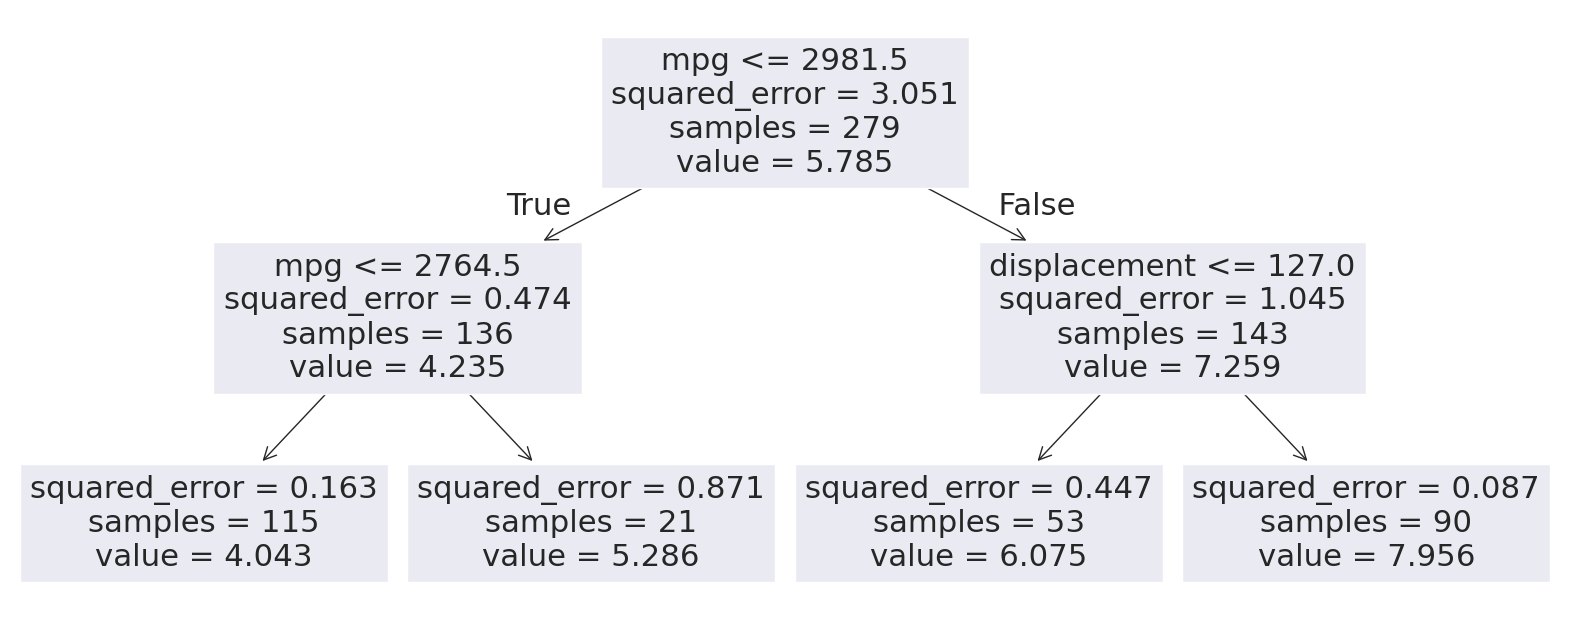

In [21]:
plt.figure(figsize=(20, 8))
sklearn.tree.plot_tree(regressor, feature_names=list(df)[:-1])
plt.show()

/nix/store/7xdz80g8z7kvj583n9a7qr4c2awlf5p3-python3-3.12.13-env/lib/python3.12/site-packages/mlxtend/plotting/decision_regions.py:346: UserWarning: You passed a edgecolor/edgecolors ('black') for an unfilled marker ('x').  Matplotlib is ignoring the edgecolor in favor of the facecolor.  This behavior may change in the future.
  ax.scatter(


NameError: name 'feature_names' is not defined

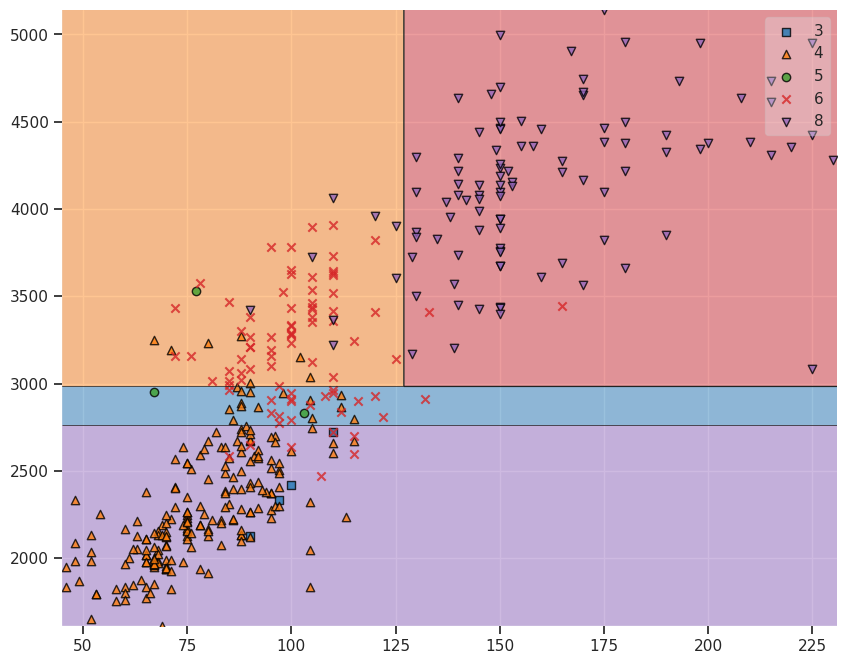

In [22]:
from mlxtend.plotting import plot_decision_regions
plt.figure(figsize = (10, 8))
plot_decision_regions(X_data, y_data.astype(np.int64), clf = regressor)
plt.xlabel(feature_names[0])
plt.ylabel(feature_names[1])
plt.grid()
